In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import tifffile
sys.path.append('/zhome/71/c/146676/main/')
import module_auxiliary as ma
from multiprocessing import Pool

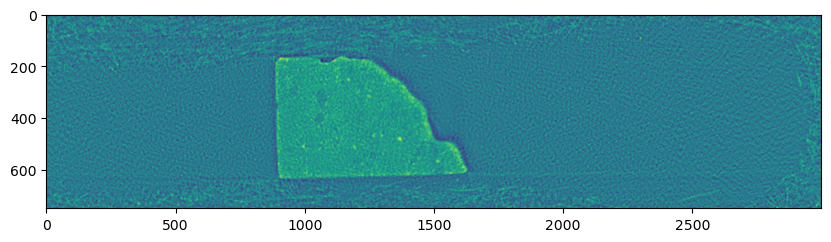

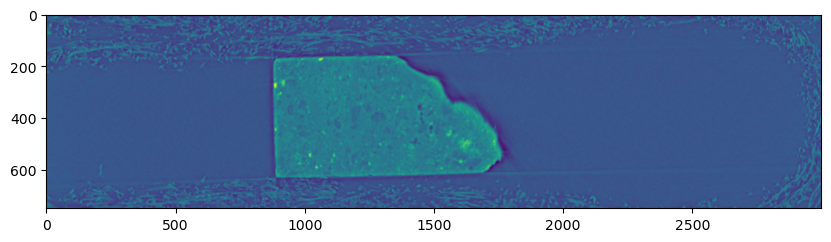

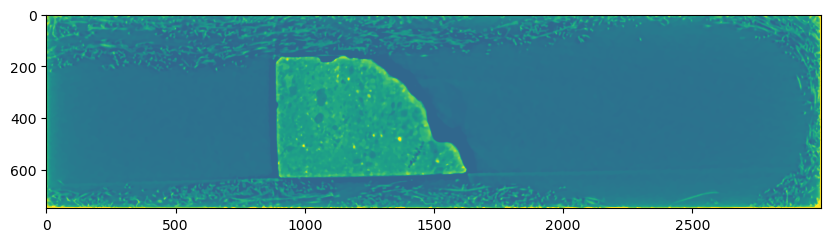

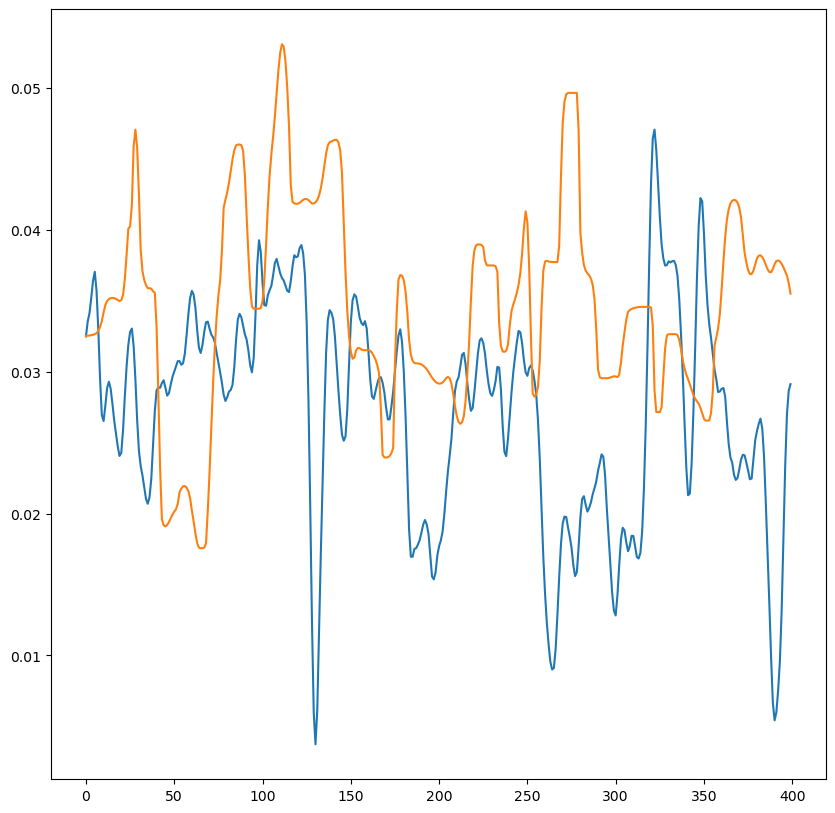

In [5]:
plt.figure(figsize=(10,10))
image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_002/slice_fbp_0040.tiff')
plt.imshow(image1)
plt.show()
#line1 = image1[400,300:700]

plt.figure(figsize=(10,10))
image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_002/slice_fbp_0100.tiff')
plt.imshow(image1)
#plt.clim([0,0.2])
plt.show()
line2 = image1[400,1000:1400]



plt.figure(figsize=(10,10))
image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/tv_recon/r_002/slice_tv_0040.tiff')
plt.imshow(image1)
plt.clim([-0.05,0.1])
plt.show()
line3 = image1[400,1000:1400]

#image1 = tifffile.imread('/dtu-compute/msaca/output/fbp_recon/slice_fbp_0880.tiff')
#plt.imshow(image1)
#plt.show()

plt.figure(figsize=(10,10))
#plt.plot(line1)
plt.plot(line2)
plt.plot(line3)
plt.show()

In [20]:
path = '/dtu-compute/msaca/sliceA_xray_pc/output/tv_recon/r_003/slice_tv_####.tiff'
A = range(64)
paths = ma.generate_paths(path,A)
ny, nx = np.shape(image1)
image = np.empty((64,ny,nx))
for i in range(64):
    image[i] = tifffile.imread(paths[i])



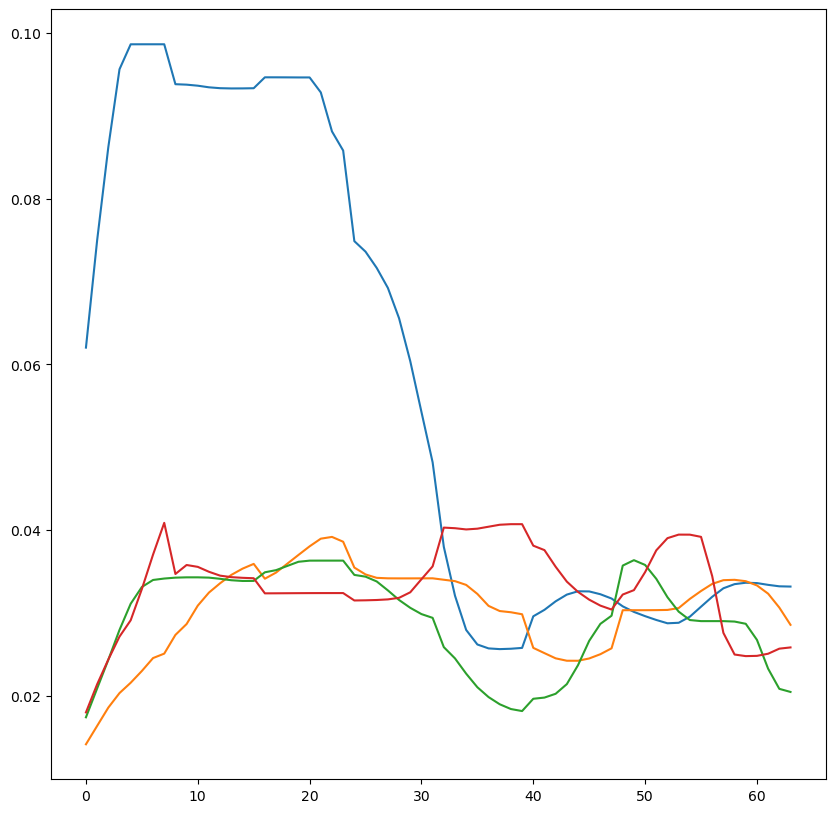

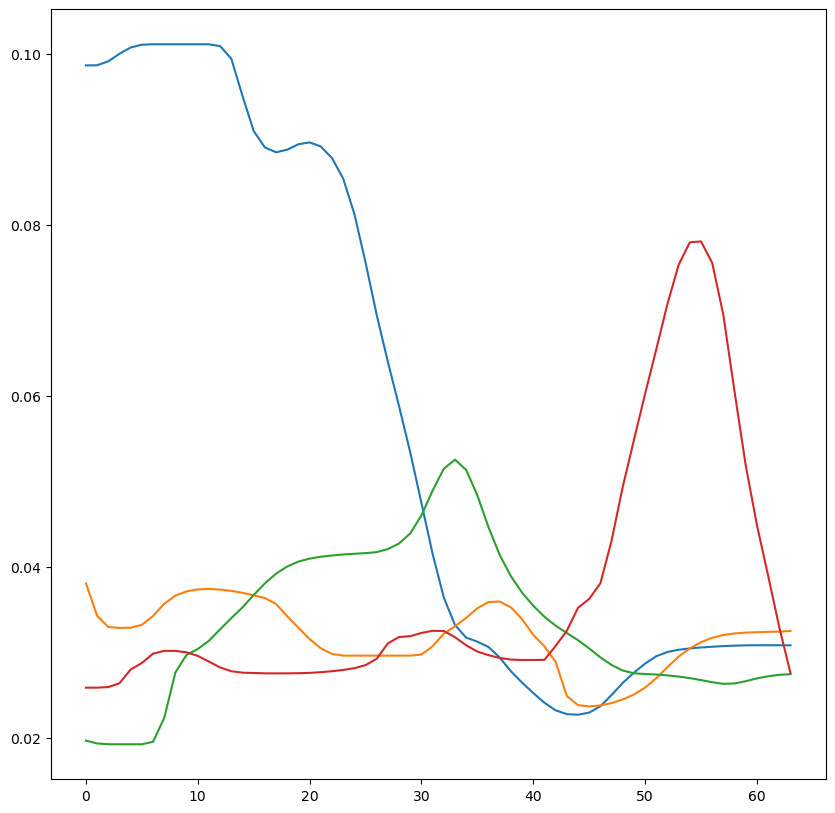

In [23]:
plt.figure(figsize=(10,10))
plt.plot(image[:,400,1000])
plt.plot(image[:,500,1000])
plt.plot(image[:,400,1100])
plt.plot(image[:,400,2000])
plt.show()


plt.figure(figsize=(10,10))
plt.plot(image[5,400:464,1000])
plt.plot(image[20,500,1000:1064])
plt.plot(image[40,400:464,1100])
plt.plot(image[63,400,2000:2064])
plt.show()

/dtu-compute/msaca/sliceA_xray_pc/output/cache/sino_003/sino_#####.tiff
/dark/dark.tiff
/compressed_XA_003_####.tiff


(700, 1748)
(300, 700, 1748)


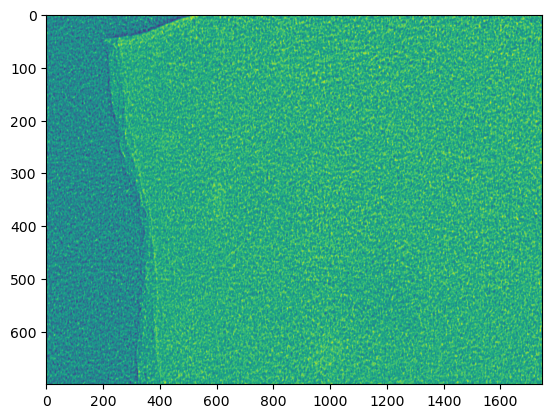

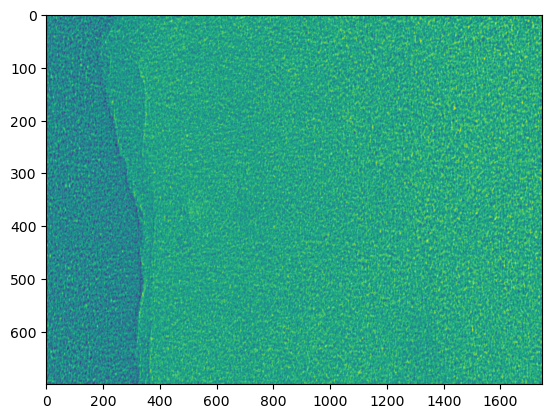

(150, 700, 3248)


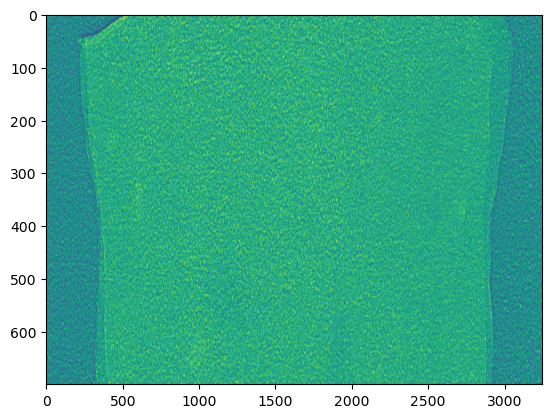

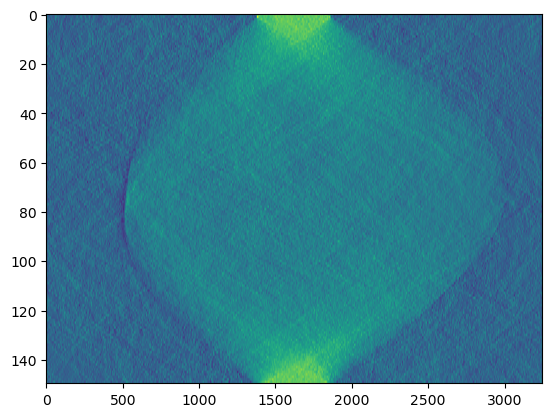

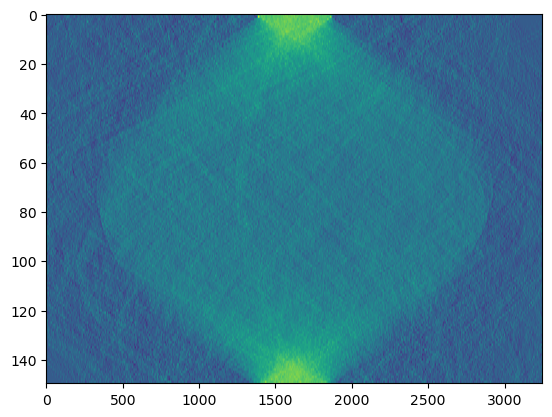

In [17]:
stride = 20
Total_angles = 6000
N_batches = 6
folders = np.array([3])
folder_idx = 0

generic_pp = '/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_###_.'
generic_pps = ma.generate_paths(generic_pp,folders)


generic_pc = '/dtu-compute/msaca/sliceA_xray_pc/output/cache/sino_###.'
generic_pcs = ma.generate_paths(generic_pc,folders)

generic_fn = '/compressed_XA_###.'
generic_fns = ma.generate_paths(generic_fn,folders)
path_prefix = generic_pps[folder_idx][:-1]
path_cache = generic_pcs[folder_idx][:-1] + '/sino_#####.tiff'
path_dark = '/dark/dark.tiff'
path_obeam = '/obeam/refHST6000.tiff'
path_postfix = generic_fns[folder_idx][:-1] + '_####.tiff'
print(path_cache)
print(path_dark)
print(path_postfix)


##########################################################
# Part 1: Preprocessing


dark = tifffile.imread(path_prefix + path_dark)[0:700]
obeam = tifffile.imread(path_prefix + path_obeam)[0:700]


N_angles = Total_angles//stride
A = np.arange(1,Total_angles + 1, stride)
paths = ma.generate_paths(path_prefix + path_postfix, A)
def loader(i):
    return tifffile.imread(paths[i])[0:700]

with Pool() as pool:
    data = pool.map(loader, np.arange(0,N_angles))

print(np.shape(data[0]))

data = np.stack(data)

print(np.shape(data))

N_slices, N_pixels = np.shape(data[0])
data = np.array(-np.log((data - dark[np.newaxis,:,:])/(obeam[np.newaxis,:,:] - dark[np.newaxis,:,:])),dtype=np.float32)

plt.imshow(data[15*5],aspect='auto')
plt.show()
plt.imshow(data[45*5],aspect='auto')
plt.show()


split_row = int(N_angles/2)
split_col = N_pixels-248
data = ma.rearrange_3d_block_matrix(data, split_row, split_col).astype(np.float32)  
N_angles, N_slices, N_pixels = np.shape(data)
print(np.shape(data))

#### FLIP the other side!!!! in the rearranbge function
plt.imshow(data[15*5],aspect='auto')
plt.show()
plt.imshow(data[:,0],aspect='auto')
plt.show()
plt.imshow(data[:,-1],aspect='auto')
plt.show()

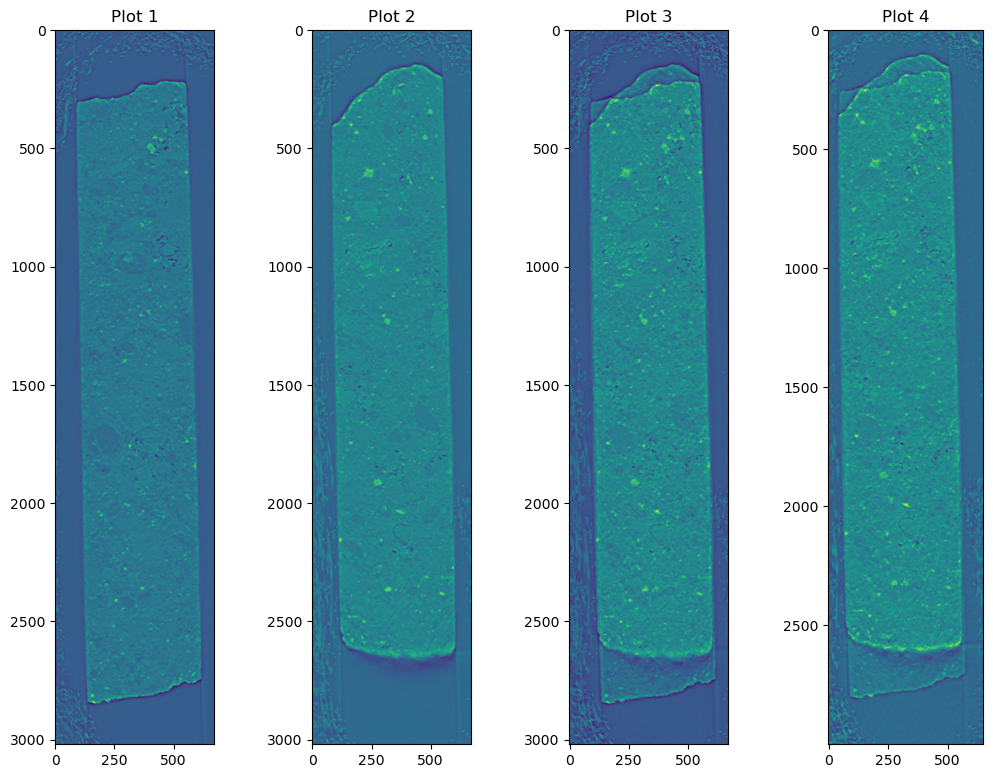

In [28]:
recons = []

slice_index = 1620
with tifffile.TiffFile(tif_file) as tif:
    recons.append(tif.pages[slice_index].asarray())  # Read the slice as a NumPy array

slice_index = 830
with tifffile.TiffFile(tif_file) as tif:
    recons.append(tif.pages[slice_index].asarray())  # Read the slice as a NumPy array

recons.append(recons[0] + recons[1])

image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice.tiff')
recons.append(image1[:3000:1,1200:1850:1])

n_plots = 4
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(8, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(recons[i])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()



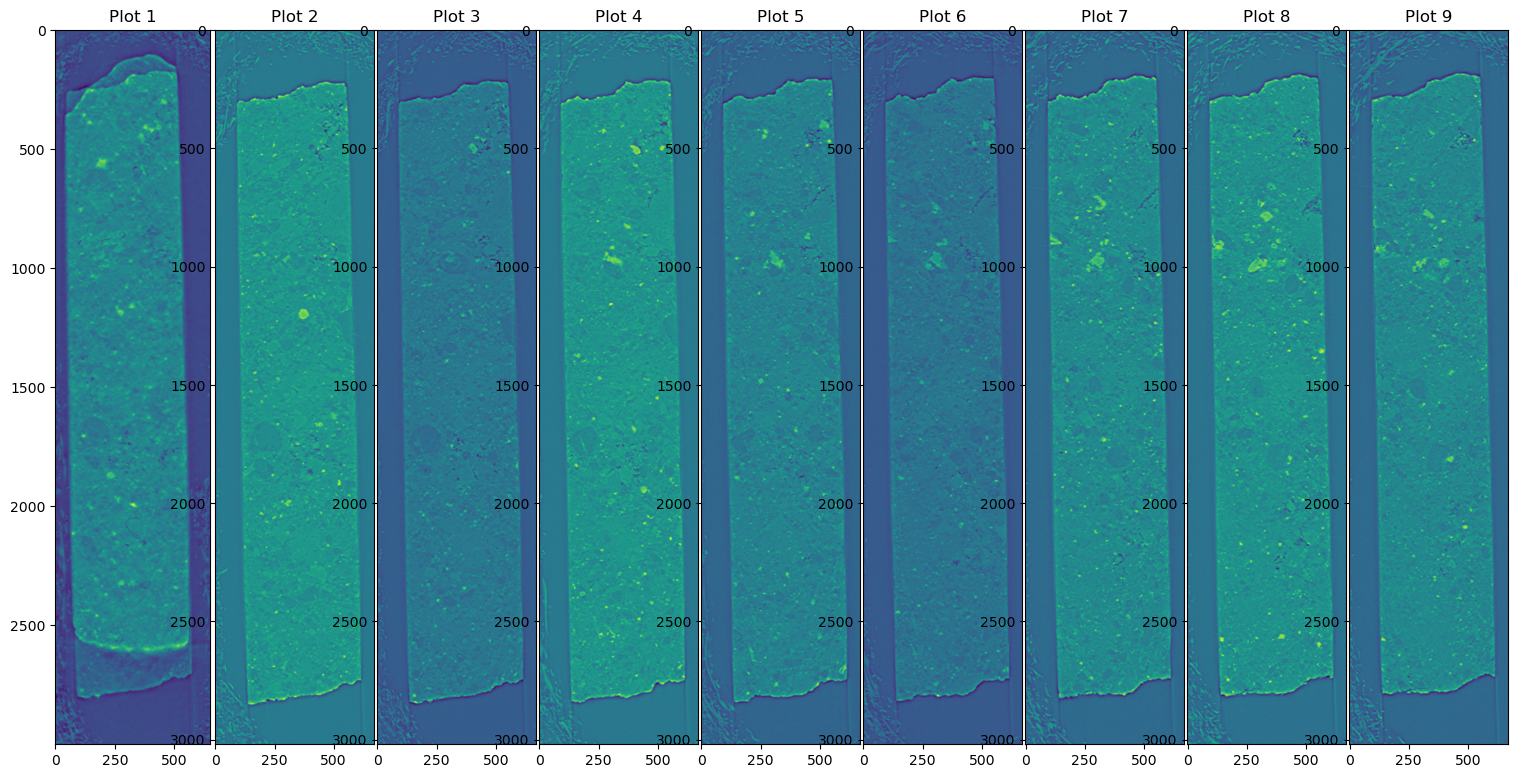

In [24]:
recons = []
image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_2.tiff')
recons.append(image1[:3000:1,1200:1850:1])

tif_file = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif'
for slice_index in np.arange(1605,2000,15):
    with tifffile.TiffFile(tif_file) as tif:
        recons.append(tif.pages[slice_index].asarray())  # Read the slice as a NumPy array
line1 = recons[4][500:1000,300]

n_plots = 9
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(12, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(recons[i])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()


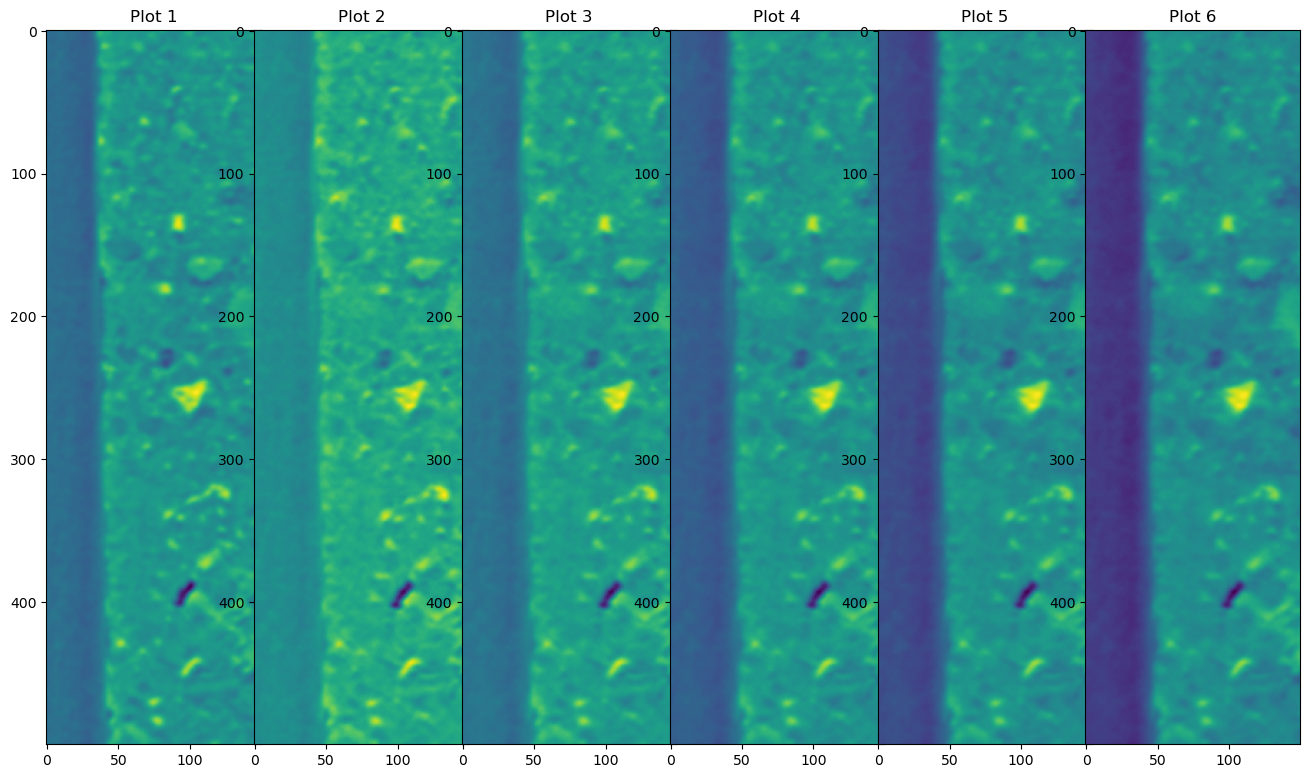

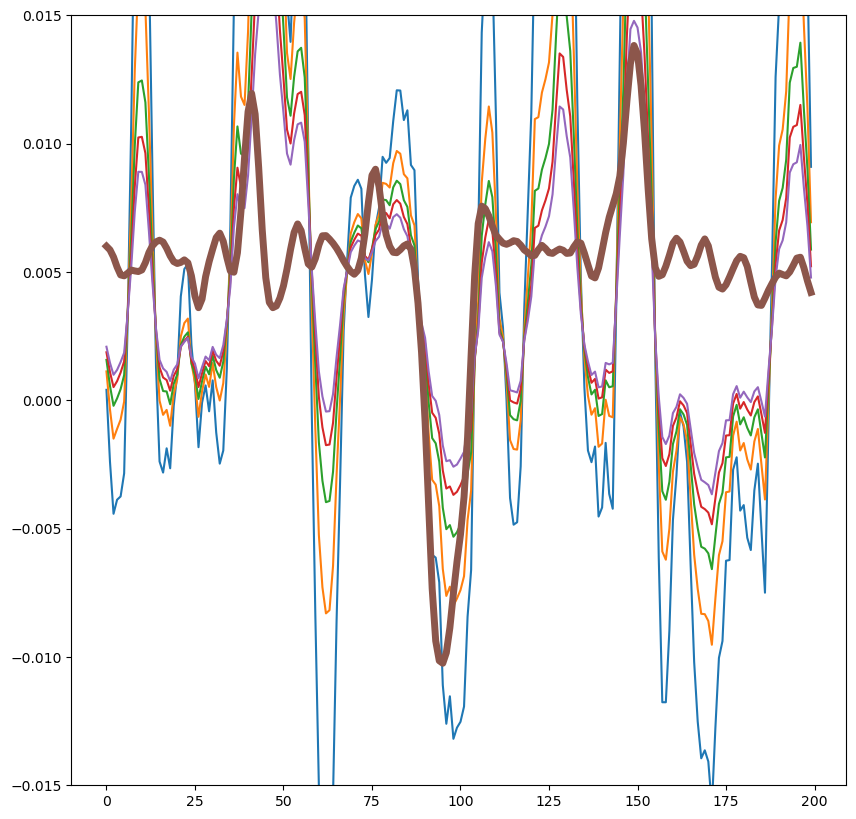

[ 1.2     1.172   1.116   1.038   0.976   0.9697  0.99    1.015   1.008
  1.003   1.016   1.072   1.151   1.204   1.234   1.247   1.232   1.185
  1.125   1.08    1.065   1.074   1.094   1.071   0.9697  0.811   0.721
  0.7886  0.963   1.08    1.177   1.268   1.302   1.238   1.113   1.007
  0.9976  1.149   1.474   1.887   2.248   2.39    2.229   1.8125  1.329
  0.955   0.7627  0.721   0.735   0.797   0.8916  1.023   1.175   1.308
  1.374   1.321   1.184   1.0625  1.037   1.104   1.209   1.281   1.283
  1.256   1.224   1.185   1.138   1.086   1.041   1.003   0.982   1.012
  1.108   1.295   1.543   1.753   1.801   1.663   1.445   1.29    1.2
  1.152   1.149   1.173   1.203   1.218   1.177   1.023   0.757   0.372
 -0.1663 -0.826  -1.467  -1.875  -2.03   -2.049  -1.967  -1.773  -1.505
 -1.26   -1.045  -0.754  -0.288   0.3516  0.969   1.377   1.513   1.493
  1.436   1.356   1.286   1.254   1.225   1.215   1.227   1.243   1.237
  1.209   1.172   1.151   1.126   1.129   1.173   1.207   1.183   

In [82]:
recon2 = []
tif_file = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif'
slice_index = 830
with tifffile.TiffFile(tif_file) as tif:
    recon2.append(tif.pages[slice_index].asarray()[545:1045,50:200])  # Read the slice as a NumPy array
line1 = recon2[0][300:,95]

image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice.tiff')
recon2.append(image1[500:1000:1,1200:1350:1])
line2 = image1[800:1000,100]



image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_1.tiff')
recon2.append(image1[500:1000:1,1200:1350:1])
line3 = image1[800:1000,100]



image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_2.tiff')
recon2.append(image1[500:1000:1,1200:1350:1])
line4 = image1[800:1000,100]



image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_3.tiff')
recon2.append(image1[500:1000:1,1200:1350:1])
line5 = image1[800:1000,100]



image1 = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/slice_4.tiff')
recon2.append(image1[500:1000:1,1200:1350:1])
line6 = image1[800:1000,100]




n_plots = 6
# Create a 1x4 grid for the subplots
fig, axes = plt.subplots(1, n_plots, figsize=(10, 2))

# Loop through the axes and plot on each subplot
for i, ax in enumerate(axes):
    ax.imshow(recon2[i])  # Example data
    ax.set_title(f'Plot {i+1}')

plt.tight_layout(pad=-20.1) 
plt.show()

plt.figure(figsize=(10,10))
plt.plot(line2)
plt.plot(line3)
plt.plot(line4)
plt.plot(line5)
plt.plot(line6)
plt.plot(line1*0.005,linewidth=5)
plt.ylim([-0.015,0.015])
plt.show()
print(line1)


In [ ]:

image1 = tifffile.imread('/dtu-compute/msaca/output/fbp_recon/slice_fbp_0400.tiff')
image2 = tifffile.imread('/dtu-compute/msaca/output/tv_recon/slice_tv_0400.tiff')
image3 = tifffile.imread('/dtu-compute/msaca/output/tv_recon/slice_tv_0101.tiff')
image4 = tifffile.imread('/dtu-compute/msaca/sliceA_neutron_psi/My_reconstructions/CoR_corrected_and_croppedFBP_idx_0400.tiff')
image4 = (image4.astype(np.float32)-30000)/128000

In [ ]:
plt.figure(figsize=(20,20))
plt.plot(image1[200,:],lw=0.3)
plt.plot(image2[200,:],lw=3)
#plt.plot(image3[200+820,:],lw=3)
plt.ylim([-0.02,0.08])
plt.show()


plt.figure(figsize=(20,20))
plt.plot(image1[:,700],lw=0.3)
plt.plot(image2[:,700],lw=3)
plt.plot(image3[820:1180,700],lw=3)
plt.ylim([-0.02,0.08])
plt.show()

plt.imshow(image1)
plt.clim([-0.1,0.1])
plt.show()
plt.imshow(image2)
plt.clim([-0.1,0.1])
plt.colorbar()
plt.show()

plt.imshow(image3)
plt.colorbar()
plt.clim([-0.1,0.1])
plt.show()
plt.imshow(image4)
plt.colorbar()
plt.clim([-0.1,0.1])
plt.show()

In [ ]:
plt.plot(image1[1000,200:1600])
plt.figure()
plt.plot(image2[1000,200:1600])
plt.figure()
plt.plot(image3[1000,200:1600])
plt.figure()
plt.plot(image4[1000,200:1600])
plt.figure()
plt.plot(image5[1000,200:1600])
plt.figure()
plt.plot(image6[1000,200:1600])
plt.figure()
plt.plot(image7[1000,200:1600])
plt.figure()
plt.plot(image8[1000,200:1600])
plt.figure()
plt.plot(image9[1000,200:1600])
plt.figure()
plt.plot(image10[1000,200:1600])
plt.figure()

In [ ]:
print(0)

skip = 200
N_slices = 2000
subslices = np.arange(300, N_slices-300, skip)
batch_size = 10
batches = subslices[::batch_size]
NN = len(batches)
print(subslices)
print(batches)
result = [subslices[i:i+batch_size] for i in range(0, len(subslices), batch_size)]
for i in range(NN):
    print(result[i])

In [1]:
import module_auxiliary as ma
file_pattern = '/dtu-compute/msaca/output/cache/sino_#####.tiff'
largest_number = ma.find_largest_number(file_pattern)

In [ ]:
print(largest_number)

In [72]:
from cil.processors import PaganinProcessor, Slicer
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer

N_pixels = 50
N_angles = 1126
N_slices = 200
angles = np.linspace(0, 360, N_angles, endpoint=True, dtype=np.float32)

ag = AcquisitionGeometry.create_Parallel3D(detector_position=[0,N_pixels//2,0])\
                            .set_angles(angles)\
                            .set_panel((N_pixels,N_slices), pixel_size=(1,1))\
                            .set_labels(labels=('vertical','angle','horizontal'))


data_batch = np.ones((50,N_angles, N_pixels))
roi = {'vertical':(0,50,1)}
processor = Slicer(roi)
processor.set_input(ag)
ag_batch = processor.get_output()
data_batch = AcquisitionData(data_batch, geometry=ag_batch)
data_batch.reorder('astra')

ag_batch.set_angles(ag_batch.angles, initial_angle=+10)
ig_batch = ag_batch.get_ImageGeometry()

In [ ]:
from cil.utilities.display import show_geometry
show_geometry(ag_batch, ig_batch)
show_geometry(ag)

In [ ]:
batch

In [1]:
import tifffile
import importlib
import sys, os
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
import module_auxiliary as ma
importlib.reload(ma)


<module 'module_auxiliary' from '/zhome/71/c/146676/main/module_auxiliary.py'>

In [19]:

folders = [1,2]
d = 20
D = 150
dataset = 'fbp'
generic_f_tv = '/dtu-compute/msaca/sliceA_xray_pc/output/tv_recon/r_###.'
generic_f_tvs = ma.generate_paths(generic_f_tv,folders)

generic_f_fbp ='/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_###.'
generic_f_fbps = ma.generate_paths(generic_f_fbp,folders)

for folder_idx in range(len(folders)-1):
    if dataset == 'fbp':
        generic_path_pre = generic_f_fbps[folder_idx][:-1]+'/slice_fbp_####.tiff'
    elif dataset == 'tv':
        generic_path_pre = generic_f_tvs[folder_idx][:-1]+'/slice_tv_####.tiff'

    if dataset == 'fbp':
        generic_path_post = generic_f_fbps[folder_idx+1][:-1]+'/slice_fbp_####.tiff'
    elif dataset == 'tv':
        generic_path_post = generic_f_tvs[folder_idx+1][:-1]+'/slice_tv_####.tiff'
    
    print(generic_path_pre)
    N_slices = ma.find_largest_number(generic_path_pre)
    path_pre = ma.generate_paths(generic_path_pre,[N_slices - d])

    A = np.arange(D)
    path_post = ma.generate_paths(generic_path_post,A)
    image_pre = tifffile.imread(path_pre[0])
    norms = np.empty(D)
    for i in A:
        image = tifffile.imread(path_post[i])
        norms[i] = np.linalg.norm(image_pre[150:650] - image[150:650],ord=1)
    w = np.argmin(norms)
    d_new = int(np.floor((w+d)/2))
    w_new = int(np.ceil((w+d)/2))


print(d_new, w_new)

/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_001/slice_fbp_####.tiff
94 94


In [20]:
print(d, w)

90 98


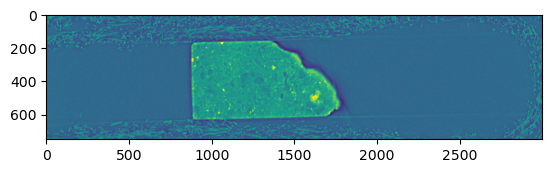

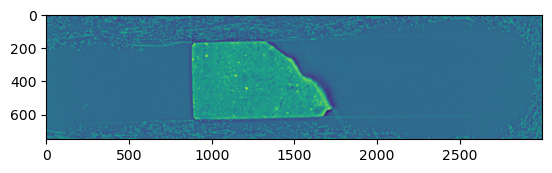

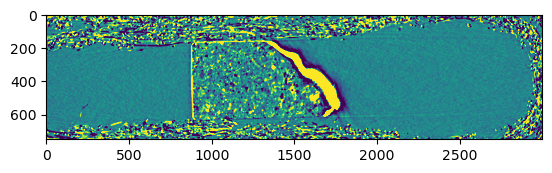

19.781445


In [ ]:
import matplotlib.pyplot as plt
path_pre = '/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_001/slice_fbp_####.tiff'
N_slices = ma.find_largest_number(path_pre)
path_pre = ma.generate_paths(path_pre,[N_slices - 20])[0]
image1 = tifffile.imread(path_pre)
plt.imshow(image1)
plt.clim([-0.05,0.1])
plt.show()

path1 = '/dtu-compute/msaca/sliceA_xray_pc/output/fbp_recon/r_002/slice_fbp_0084.tiff'
image2 = tifffile.imread(path1)
plt.imshow(image2)
plt.clim([-0.05,0.1])
plt.show()

plt.imshow(image1 - image2)
plt.clim([-0.02,0.02])
plt.show()

print(np.linalg.norm(image1 - image2))